In [71]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import zipfile
import os

zip_path = '/content/drive/MyDrive/ML/Datasets/realwaste.zip'
extract_path = '/content/realwaste_dataset'

# Create extraction folder if it doesn’t exist
os.makedirs(extract_path, exist_ok=True)

# Extract dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)




In [73]:
import os
import shutil
import random

source_dir = '/content/realwaste_dataset/realwaste-main/RealWaste'
base_dir = '/content/realwaste_split'  # new folder to store the split dataset

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Create directories
for dir_path in [train_dir, val_dir, test_dir]:
    os.makedirs(dir_path, exist_ok=True)

#Split the data
split_ratio = {'train': 0.7, 'val': 0.15, 'test': 0.15}

for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    # List all images in the class
    images = os.listdir(class_path)
    random.shuffle(images)

    # Compute split indices
    total = len(images)
    train_count = int(split_ratio['train'] * total)
    val_count = int(split_ratio['val'] * total)

    train_imgs = images[:train_count]
    val_imgs = images[train_count:train_count + val_count]
    test_imgs = images[train_count + val_count:]

    # Create subdirectories for the class in train/val/test
    for split, img_list in zip(['train', 'val', 'test'], [train_imgs, val_imgs, test_imgs]):
        split_class_dir = os.path.join(base_dir, split, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

        # Copy images to new directories
        for img in img_list:
            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_dir, img)
            shutil.copy2(src, dst)

    print(f" {class_name}: {train_count} train, {val_count} val, {len(test_imgs)} test")

print("\n Dataset successfully split into train, val, and test folders!")
print("Root directory:", base_dir)


 Cardboard: 322 train, 69 val, 70 test
 Miscellaneous Trash: 346 train, 74 val, 75 test
 Vegetation: 305 train, 65 val, 66 test
 Textile Trash: 222 train, 47 val, 49 test
 Food Organics: 287 train, 61 val, 63 test
 Plastic: 644 train, 138 val, 139 test
 Glass: 294 train, 63 val, 63 test
 Paper: 350 train, 75 val, 75 test
 Metal: 553 train, 118 val, 119 test

 Dataset successfully split into train, val, and test folders!
Root directory: /content/realwaste_split


In [74]:
#import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import time
import copy
import os


In [75]:
# Splited data path
data_dir = '/content/realwaste_split'


In [76]:
#Preprocessing and Augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],  # Imagenet mean
                             [0.229, 0.224, 0.225])  # Imagenet std
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}


In [77]:

image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val']
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2)
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
print("Classes:", class_names)


Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


In [78]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Load pretrained ResNet-50
model_ft = models.resnet50(pretrained=True)

# Freeze lower layers slightly to prevent overfitting (optional but helps small datasets)
for name, param in model_ft.named_parameters():
    if "layer4" not in name:  # fine-tune only the last ResNet block + classifier
        param.requires_grad = False

# Replace the final fully connected layer
num_ftrs = model_ft.fc.in_features

model_ft.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.SiLU(inplace=True),

    nn.Linear(512, 128),
    nn.BatchNorm1d(128),
    nn.Dropout(0.3),
    nn.SiLU(inplace=True),

    nn.Linear(128, len(class_names))
)

model_ft = model_ft.to(device)


cuda


# For Adam

In [79]:
#defined the Loss
criterion = nn.CrossEntropyLoss()

# Only parameters of final layer are being optimized
optimizer_ft = optim.Adam(model_ft.fc.parameters(), lr=0.001)

# Learning rate scheduler (optional)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_ft, T_0=10, T_mult=1, eta_min=1e-6
)



In [80]:
#training
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    train_loss_history, val_loss_history = [], []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 30)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                train_loss_history.append(epoch_loss)
            else:
                val_loss_history.append(epoch_loss)

            # Deep copy the model if best accuracy
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, train_loss_history, val_loss_history

model_ft, train_loss, val_loss = train_model(model_ft, criterion, optimizer_ft, scheduler, num_epochs=10)


Epoch 1/10
------------------------------
train Loss: 1.0060 Acc: 0.6691
val Loss: 0.5954 Acc: 0.8080

Epoch 2/10
------------------------------
train Loss: 0.6688 Acc: 0.7694
val Loss: 0.5203 Acc: 0.8209

Epoch 3/10
------------------------------
train Loss: 0.5676 Acc: 0.8084
val Loss: 0.4883 Acc: 0.8267

Epoch 4/10
------------------------------
train Loss: 0.5024 Acc: 0.8247
val Loss: 0.3372 Acc: 0.8851

Epoch 5/10
------------------------------
train Loss: 0.4289 Acc: 0.8516
val Loss: 0.3096 Acc: 0.8989

Epoch 6/10
------------------------------
train Loss: 0.3801 Acc: 0.8776
val Loss: 0.2583 Acc: 0.9140

Epoch 7/10
------------------------------
train Loss: 0.3338 Acc: 0.8874
val Loss: 0.2560 Acc: 0.9203

Epoch 8/10
------------------------------
train Loss: 0.3114 Acc: 0.8920
val Loss: 0.2115 Acc: 0.9381

Epoch 9/10
------------------------------
train Loss: 0.2920 Acc: 0.9020
val Loss: 0.2094 Acc: 0.9345

Epoch 10/10
------------------------------
train Loss: 0.2684 Acc: 0.9117

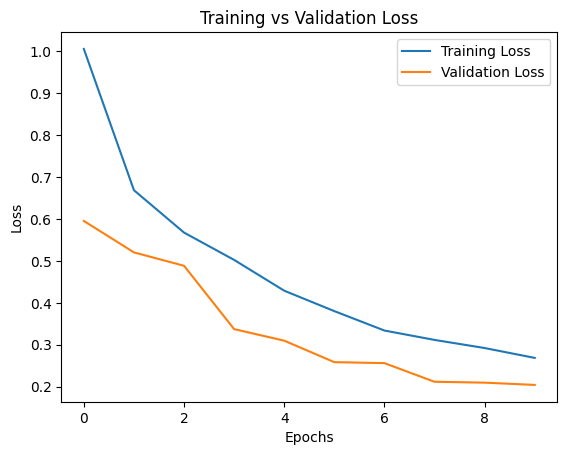

In [81]:

plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()


In [ ]:
torch.save(model_ft.state_dict(), '/content/drive/MyDrive/resnet50_waste_finetuned.pth')



In [83]:
from google.colab import files

# Save temporarily in Colab
torch.save(model_ft.state_dict(), 'resnet50_realwaste_Adam.pth')

# Download to your local computer
#files.download('resnet50_realwaste_Adam.pth')


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import random
import os

#load test dataset
test_dir = '/content/realwaste_split/test'

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load dataset
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
class_names = test_dataset.classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")





In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = models.resnet50(pretrained=False)
num_ftrs = model.fc.in_features

# Define the correct custom classifier head (match checkpoint structure)
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.SiLU(inplace=True),

    nn.Linear(512, 128),
    nn.BatchNorm1d(128),
    nn.Dropout(0.3),
    nn.SiLU(inplace=True),

    nn.Linear(128, len(class_names))
)

# Load trained weights
state_dict = torch.load('/content/resnet50_realwaste_Adam.pth', map_location=device)

# If the checkpoint was saved using DataParallel, remove "module." prefix
from collections import OrderedDict
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_key = k.replace("module.", "")  # remove 'module.' if present
    new_state_dict[new_key] = v

model.load_state_dict(new_state_dict)

# Move to device and set eval mode
model = model.to(device)
model.eval()

print("✅ Model loaded successfully from /content/resnet50_realwaste_Adam.pth")


cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded successfully from /content/resnet50_realwaste_Adam.pth


In [ ]:

# def imshow(inp, title=None):
#     """Display an image tensor."""
#     inp = inp.numpy().transpose((1, 2, 0))
#     mean = np.array([0.485, 0.456, 0.406])
#     std = np.array([0.229, 0.224, 0.225])
#     inp = std * inp + mean
#     inp = np.clip(inp, 0, 1)
#     plt.imshow(inp)
#     plt.axis('off')
#     if title:
#         plt.title(title)

# # Pick 10 random test images
# samples = random.sample(range(len(test_dataset)), 10)

# plt.figure(figsize=(16, 10))
# for i, idx in enumerate(samples):
#     image, label = test_dataset[idx]
#     input_tensor = image.unsqueeze(0).to(device)

#     # Predict
#     with torch.no_grad():
#         outputs = model(input_tensor)
#         _, preds = torch.max(outputs, 1)

#     gt_label = class_names[label]
#     pred_label = class_names[preds[0]]
#     color = 'green' if gt_label == pred_label else 'red'

#     plt.subplot(2, 5, i + 1)
#     imshow(image.cpu(), title=f"GT: {gt_label}\nPred: {pred_label}")
#     plt.title(f"GT: {gt_label}\nPred: {pred_label}", color=color, fontsize=9)

# plt.tight_layout()
# plt.show()



 Test Accuracy of Fine-Tuned ResNet50: 93.14%

Classification Report:
                     precision    recall  f1-score   support

          Cardboard       0.97      0.92      0.94       223
      Food Organics       0.96      0.95      0.95       202
              Glass       0.96      0.95      0.96       197
              Metal       0.95      0.90      0.92       372
Miscellaneous Trash       0.92      0.86      0.89       233
              Paper       0.93      0.94      0.94       238
            Plastic       0.88      0.96      0.91       436
      Textile Trash       0.92      0.93      0.93       153
         Vegetation       0.95      0.99      0.97       206

           accuracy                           0.93      2260
          macro avg       0.94      0.93      0.93      2260
       weighted avg       0.93      0.93      0.93      2260



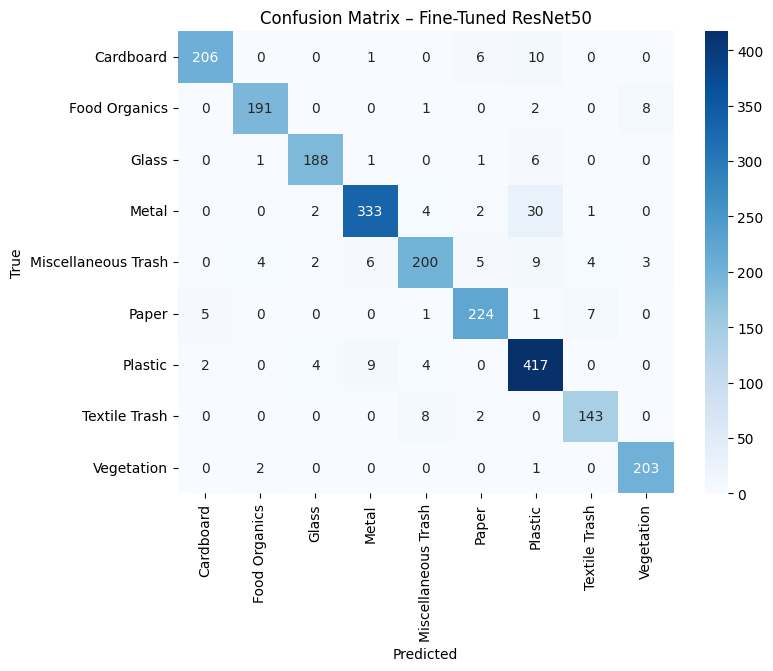

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import pandas as pd


test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Metrics
acc = accuracy_score(y_true, y_pred)
print(f"\n Test Accuracy of Fine-Tuned ResNet50: {acc*100:.2f}%\n")

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)

plt.figure(figsize=(8,6))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Fine-Tuned ResNet50")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()


# For SGD

In [88]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Load pretrained ResNet-50
model_ft = models.resnet50(pretrained=True)

# Freeze lower layers slightly to prevent overfitting (optional but helps small datasets)
for name, param in model_ft.named_parameters():
    if "layer4" not in name:  # fine-tune only the last ResNet block + classifier
        param.requires_grad = False

# Replace the final fully connected layer
num_ftrs = model_ft.fc.in_features

model_ft.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.SiLU(inplace=True),

    nn.Linear(512, 128),
    nn.BatchNorm1d(128),
    nn.Dropout(0.3),
    nn.SiLU(inplace=True),

    nn.Linear(128, len(class_names))
)

model_ft = model_ft.to(device)


cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [89]:
criterion = nn.CrossEntropyLoss()
# Only parameters of final layer are being optimized
optimizer_ft = optim.SGD(model_ft.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_ft, T_0=10, T_mult=1, eta_min=1e-6
)


In [90]:
#training
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    train_loss_history, val_loss_history = [], []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 30)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                train_loss_history.append(epoch_loss)
            else:
                val_loss_history.append(epoch_loss)

            # Deep copy the model if best accuracy
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, train_loss_history, val_loss_history

model_ft, train_loss, val_loss = train_model(model_ft, criterion, optimizer_ft, scheduler, num_epochs=10)


Epoch 1/10
------------------------------
train Loss: 2.1425 Acc: 0.2016
val Loss: 1.9666 Acc: 0.3929

Epoch 2/10
------------------------------
train Loss: 1.8983 Acc: 0.3631
val Loss: 1.7662 Acc: 0.5252

Epoch 3/10
------------------------------
train Loss: 1.7145 Acc: 0.4571
val Loss: 1.6147 Acc: 0.5755

Epoch 4/10
------------------------------
train Loss: 1.6045 Acc: 0.5090
val Loss: 1.5140 Acc: 0.6089

Epoch 5/10
------------------------------
train Loss: 1.5119 Acc: 0.5547
val Loss: 1.4498 Acc: 0.6156

Epoch 6/10
------------------------------
train Loss: 1.4553 Acc: 0.5712
val Loss: 1.4067 Acc: 0.6334

Epoch 7/10
------------------------------
train Loss: 1.4227 Acc: 0.5806
val Loss: 1.3727 Acc: 0.6352

Epoch 8/10
------------------------------
train Loss: 1.4021 Acc: 0.5784
val Loss: 1.3587 Acc: 0.6494

Epoch 9/10
------------------------------
train Loss: 1.3864 Acc: 0.5890
val Loss: 1.3365 Acc: 0.6423

Epoch 10/10
------------------------------
train Loss: 1.3797 Acc: 0.5829

In [91]:
from google.colab import files

# Save temporarily in Colab
torch.save(model_ft.state_dict(), 'resnet50_realwaste_SGD.pth')

# Download to your local computer
#files.download('resnet50_realwaste_SGD.pth')


In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = models.resnet50(pretrained=False)
num_ftrs = model.fc.in_features

# Define the correct custom classifier head (match checkpoint structure)
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.SiLU(inplace=True),

    nn.Linear(512, 128),
    nn.BatchNorm1d(128),
    nn.Dropout(0.3),
    nn.SiLU(inplace=True),

    nn.Linear(128, len(class_names))
)

# Load trained weights
state_dict = torch.load('/content/resnet50_realwaste_SGD.pth', map_location=device)

# If the checkpoint was saved using DataParallel, remove "module." prefix
from collections import OrderedDict
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_key = k.replace("module.", "")  # remove 'module.' if present
    new_state_dict[new_key] = v

model.load_state_dict(new_state_dict)

# Move to device and set eval mode
model = model.to(device)
model.eval()

print("✅ Model loaded successfully from /content/resnet50_realwaste_SGD.pth")


cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded successfully from /content/resnet50_realwaste_SGD.pth



 Test Accuracy of Fine-Tuned ResNet50: 63.89%

Classification Report:
                     precision    recall  f1-score   support

          Cardboard       0.58      0.73      0.65       223
      Food Organics       0.67      0.84      0.74       202
              Glass       0.87      0.38      0.53       197
              Metal       0.61      0.82      0.70       372
Miscellaneous Trash       0.72      0.08      0.14       233
              Paper       0.62      0.52      0.56       238
            Plastic       0.60      0.73      0.66       436
      Textile Trash       0.68      0.52      0.59       153
         Vegetation       0.73      0.93      0.82       206

           accuracy                           0.64      2260
          macro avg       0.68      0.62      0.60      2260
       weighted avg       0.66      0.64      0.61      2260



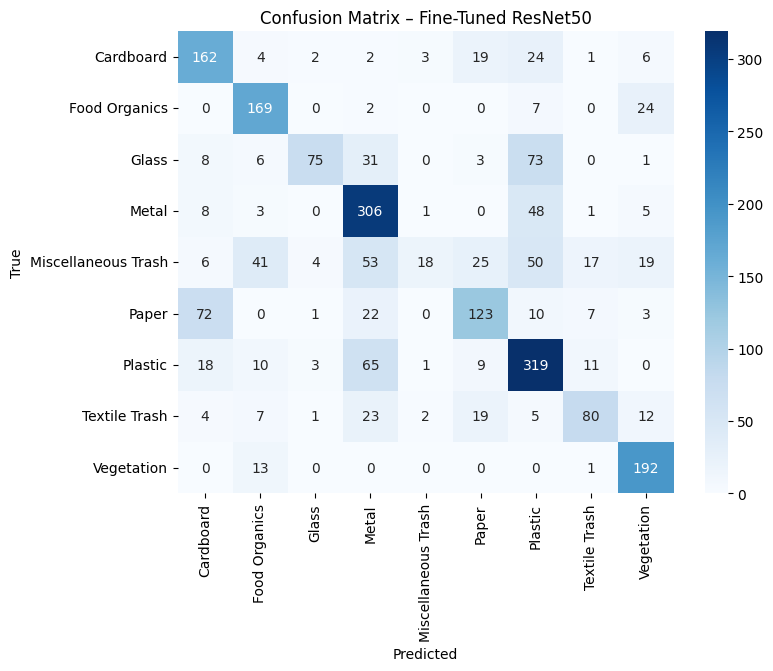

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import pandas as pd


test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Metrics
acc = accuracy_score(y_true, y_pred)
print(f"\n Test Accuracy of Fine-Tuned ResNet50: {acc*100:.2f}%\n")

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)

plt.figure(figsize=(8,6))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Fine-Tuned ResNet50")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()


# SGD Momentum

In [94]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Load pretrained ResNet-50
model_ft = models.resnet50(pretrained=True)

# Freeze lower layers slightly to prevent overfitting (optional but helps small datasets)
for name, param in model_ft.named_parameters():
    if "layer4" not in name:  # fine-tune only the last ResNet block + classifier
        param.requires_grad = False

# Replace the final fully connected layer
num_ftrs = model_ft.fc.in_features

model_ft.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.SiLU(inplace=True),

    nn.Linear(512, 128),
    nn.BatchNorm1d(128),
    nn.Dropout(0.3),
    nn.SiLU(inplace=True),

    nn.Linear(128, len(class_names))
)

model_ft = model_ft.to(device)


cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [95]:
criterion = nn.CrossEntropyLoss()
# Optimizer - SGD with momentum
optimizer_ft = optim.SGD(model_ft.fc.parameters(), lr=0.001, momentum=0.9)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_ft, T_0=10, T_mult=1, eta_min=1e-6
)


In [96]:
#training
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    train_loss_history, val_loss_history = [], []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 30)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                train_loss_history.append(epoch_loss)
            else:
                val_loss_history.append(epoch_loss)

            # Deep copy the model if best accuracy
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, train_loss_history, val_loss_history

model_ft, train_loss, val_loss = train_model(model_ft, criterion, optimizer_ft, scheduler, num_epochs=10)


Epoch 1/10
------------------------------
train Loss: 1.5761 Acc: 0.4785
val Loss: 1.0969 Acc: 0.6775

Epoch 2/10
------------------------------
train Loss: 1.0282 Acc: 0.6871
val Loss: 0.8352 Acc: 0.7617

Epoch 3/10
------------------------------
train Loss: 0.8417 Acc: 0.7387
val Loss: 0.7081 Acc: 0.7884

Epoch 4/10
------------------------------
train Loss: 0.7404 Acc: 0.7652
val Loss: 0.6430 Acc: 0.7996

Epoch 5/10
------------------------------
train Loss: 0.6777 Acc: 0.7855
val Loss: 0.5808 Acc: 0.8160

Epoch 6/10
------------------------------
train Loss: 0.6333 Acc: 0.8016
val Loss: 0.5329 Acc: 0.8352

Epoch 7/10
------------------------------
train Loss: 0.6126 Acc: 0.8037
val Loss: 0.5095 Acc: 0.8419

Epoch 8/10
------------------------------
train Loss: 0.5836 Acc: 0.8133
val Loss: 0.5034 Acc: 0.8463

Epoch 9/10
------------------------------
train Loss: 0.5679 Acc: 0.8251
val Loss: 0.4902 Acc: 0.8450

Epoch 10/10
------------------------------
train Loss: 0.5718 Acc: 0.8198

In [97]:
from google.colab import files

# Save temporarily in Colab
torch.save(model_ft.state_dict(), 'resnet50_realwaste_SGD_momentum.pth')

# Download to your local computer
#files.download('resnet50_realwaste_SGD_momentum.pth')


In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = models.resnet50(pretrained=False)
num_ftrs = model.fc.in_features

# Define the correct custom classifier head (match checkpoint structure)
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.SiLU(inplace=True),

    nn.Linear(512, 128),
    nn.BatchNorm1d(128),
    nn.Dropout(0.3),
    nn.SiLU(inplace=True),

    nn.Linear(128, len(class_names))
)

# Load trained weights
state_dict = torch.load('/content/resnet50_realwaste_SGD_momentum.pth', map_location=device)

# If the checkpoint was saved using DataParallel, remove "module." prefix
from collections import OrderedDict
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_key = k.replace("module.", "")  # remove 'module.' if present
    new_state_dict[new_key] = v

model.load_state_dict(new_state_dict)

# Move to device and set eval mode
model = model.to(device)
model.eval()

print("✅ Model loaded successfully from /content/resnet50_realwaste_SGD_momentum.pth")


cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded successfully from /content/resnet50_realwaste_SGD_momentum.pth



 Test Accuracy of Fine-Tuned ResNet50: 85.13%

Classification Report:
                     precision    recall  f1-score   support

          Cardboard       0.91      0.83      0.87       223
      Food Organics       0.86      0.91      0.89       202
              Glass       0.91      0.85      0.88       197
              Metal       0.84      0.89      0.86       372
Miscellaneous Trash       0.93      0.55      0.69       233
              Paper       0.83      0.88      0.86       238
            Plastic       0.77      0.89      0.83       436
      Textile Trash       0.84      0.86      0.85       153
         Vegetation       0.92      0.97      0.94       206

           accuracy                           0.85      2260
          macro avg       0.87      0.85      0.85      2260
       weighted avg       0.86      0.85      0.85      2260



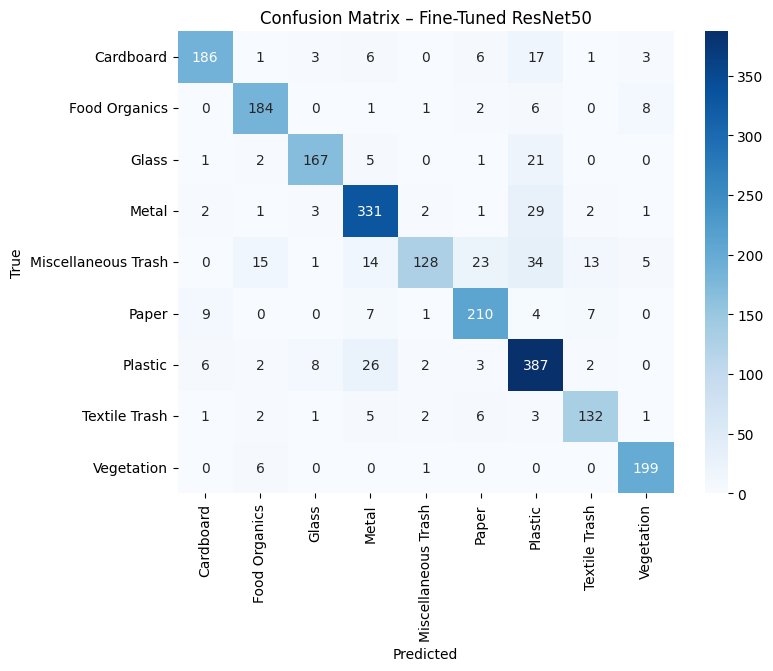

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import pandas as pd


test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Metrics
acc = accuracy_score(y_true, y_pred)
print(f"\n Test Accuracy of Fine-Tuned ResNet50: {acc*100:.2f}%\n")

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)

plt.figure(figsize=(8,6))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Fine-Tuned ResNet50")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()
